# IMG_01 - Image Audit

## TFM - Skin Lesion Classification (ISIC 2024 / SLICE-3D)

### Objective

The purpose of this notebook is to perform a complete audit of the image dataset before any preprocessing or model development.

The metadata audit has already been completed in EDA_01.ipynb. However, image quality, image availability and image characteristics have not yet been validated.

This notebook aims to answer the following questions:

1. How many image files exist physically?
2. Do image files match metadata records?
3. Are there missing images?
4. Are there corrupted images?
5. What image formats are present?
6. What image resolutions exist?
7. What is the width and height distribution?
8. What disk space does the dataset occupy?
9. What resize strategy should be adopted?
10. Are there potential issues that could affect model training?

The results obtained in this notebook will guide all subsequent preprocessing and deep learning decisions.

In [12]:
# import standard libraries

from pathlib import Path

import os
import numpy as np
import pandas as pd

from PIL import Image

import matplotlib.pyplot as plt
# import seaborn as sns

from tqdm.auto import tqdm

# Project utilities
from skin_lesion_ai.utils.data_utils import path, load_raw_metadata

In [13]:
# Load raw metadata

df1, df2, df3 = load_raw_metadata()

print("df1 - ground_truth:", df1.shape)
print("df2 - supplement:", df2.shape)
print("df3 - metadata:", df3.shape)

D:\Workspace\research\ub_master_thesis\my-image-classifier\src\skin_lesion_ai\utils\data_utils.py:44: DtypeWarning: Columns (0: iddx_5) have mixed types. Specify dtype option on import or set low_memory=False.
  supplement = pd.read_csv(path(raw["supplement_csv"]))


df1 - ground_truth: (401059, 2)
df2 - supplement: (401059, 13)
df3 - metadata: (401059, 42)


## Image Directory Configuration

In [14]:
# Check current working directory and path to images

print("Current working directory:")
print(os.getcwd())

print("\nCurrent Path:")
print(Path.cwd())

# repo_root = get_project_root()

# IMAGE_DIR = (
#     repo_root
#     / "data"
#     / "raw"
#     / "images"
# )

IMAGE_DIR = path("data/raw/images")
# IMAGE_DIR = paths["raw_images"]

print("\nIMAGE_DIR: ", IMAGE_DIR)
print(IMAGE_DIR.exists())

Current working directory:
d:\Workspace\research\ub_master_thesis\my-image-classifier\notebooks

Current Path:
d:\Workspace\research\ub_master_thesis\my-image-classifier\notebooks

IMAGE_DIR:  D:\Workspace\research\ub_master_thesis\my-image-classifier\data\raw\images
True


## Physical Image Count

Count all image files available in the dataset directory.

In [15]:
# List all image files in the directory

image_files = sorted(list(IMAGE_DIR.glob("*.jpg")))

len(image_files)
image_files

[WindowsPath('D:/Workspace/research/ub_master_thesis/my-image-classifier/data/raw/images/ISIC_0015670.jpg'),
 WindowsPath('D:/Workspace/research/ub_master_thesis/my-image-classifier/data/raw/images/ISIC_0015845.jpg'),
 WindowsPath('D:/Workspace/research/ub_master_thesis/my-image-classifier/data/raw/images/ISIC_0015864.jpg'),
 WindowsPath('D:/Workspace/research/ub_master_thesis/my-image-classifier/data/raw/images/ISIC_0015902.jpg'),
 WindowsPath('D:/Workspace/research/ub_master_thesis/my-image-classifier/data/raw/images/ISIC_0024200.jpg'),
 WindowsPath('D:/Workspace/research/ub_master_thesis/my-image-classifier/data/raw/images/ISIC_0035502.jpg'),
 WindowsPath('D:/Workspace/research/ub_master_thesis/my-image-classifier/data/raw/images/ISIC_0051648.jpg'),
 WindowsPath('D:/Workspace/research/ub_master_thesis/my-image-classifier/data/raw/images/ISIC_0051665.jpg'),
 WindowsPath('D:/Workspace/research/ub_master_thesis/my-image-classifier/data/raw/images/ISIC_0051710.jpg'),
 WindowsPath('D:/Wo

## Metadata vs Physical Files Validation

In [16]:
# Check for duplicates in metadata and images

metadata_ids = set(df1["isic_id"])

image_ids = {img.stem for img in image_files}

print("Metadata:", len(metadata_ids))
print("Images:", len(image_ids))

Metadata: 401059
Images: 401059


In [17]:
# Find missing images in the metadata

missing_images = metadata_ids - image_ids

len(missing_images)

0

In [18]:
# Find extra images not in metadata

extra_images = image_ids - metadata_ids

len(extra_images)

0

## File Extensions

In [19]:
# Check file extensions of images

extensions = {}

for file in image_files:
    ext = file.suffix.lower()
    extensions[ext] = extensions.get(ext, 0) + 1

pd.Series(extensions)

.jpg    401059
dtype: int64

## Image Resolution Audit

In [20]:
# Analyze image resolutions

sample_size = min(401059, len(image_files))

sample_files = np.random.choice(image_files, sample_size, replace=False)

image_stats = []

for img_path in tqdm(sample_files):
    try:
        with Image.open(img_path) as img:
            width, height = img.size

            image_stats.append(
                {"width": width, "height": height, "aspect_ratio": width / height}
            )

    except Exception:
        pass

resolution_df = pd.DataFrame(image_stats)

resolution_df.describe()

  0%|          | 0/401059 [00:00<?, ?it/s]

,width,height,aspect_ratio
count,401059.000000,401059.000000,401059.0
mean,133.245316,133.245316,1.0
std,18.271392,18.271392,0.0
min,41.000000,41.000000,1.0
25%,121.000000,121.000000,1.0
50%,131.000000,131.000000,1.0
75%,143.000000,143.000000,1.0
max,269.000000,269.000000,1.0


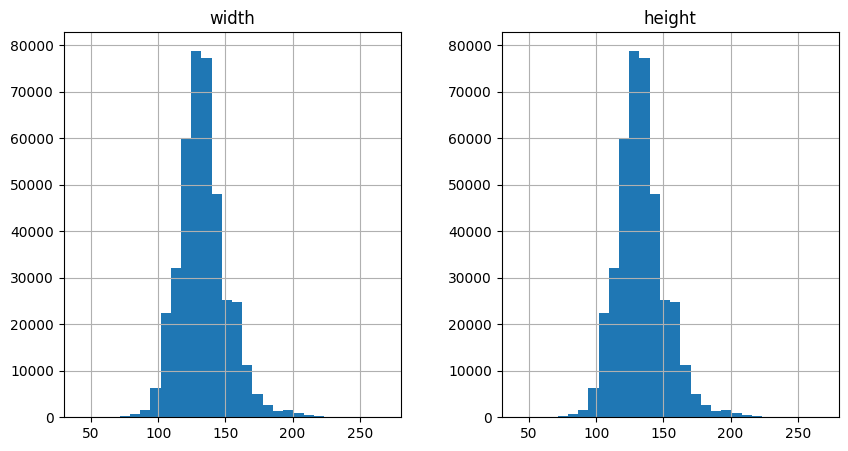

In [21]:
# Plot histograms of width and height

resolution_df[["width", "height"]].hist(bins=30, figsize=(10, 5))

plt.show()

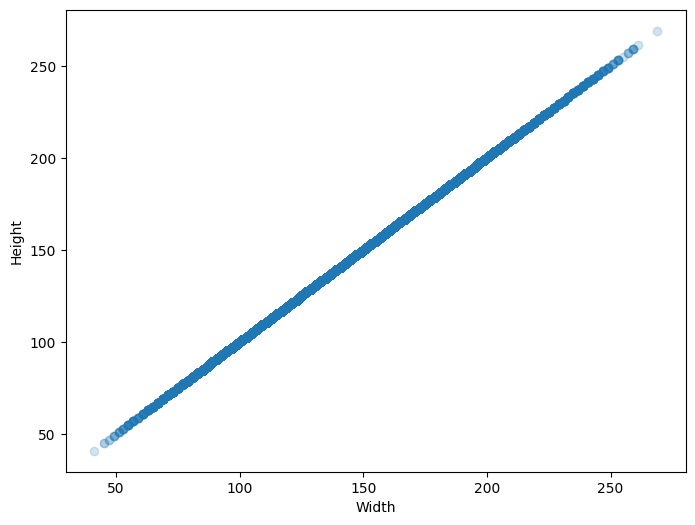

In [22]:
# Plot scatter of width vs height

plt.figure(figsize=(8, 6))

plt.scatter(resolution_df["width"], resolution_df["height"], alpha=0.2)

plt.xlabel("Width")
plt.ylabel("Height")

plt.show()

## Corrupted Images Audit

In [23]:
# Check for corrupted images

corrupted_files = []

for img_path in tqdm(image_files):
    try:
        with Image.open(img_path) as img:
            img.verify()

    except Exception:
        corrupted_files.append(img_path.name)

  0%|          | 0/401059 [00:00<?, ?it/s]

In [24]:
# Count corrupted images

len(corrupted_files)

0

## Dataset Disk Usage

In [25]:
# Calculate total size of images in GB

total_bytes = sum(os.path.getsize(file) for file in image_files)

total_gb = total_bytes / (1024**3)

print(f"{total_gb:.2f} GB")

1.06 GB


## Random Image Visualization

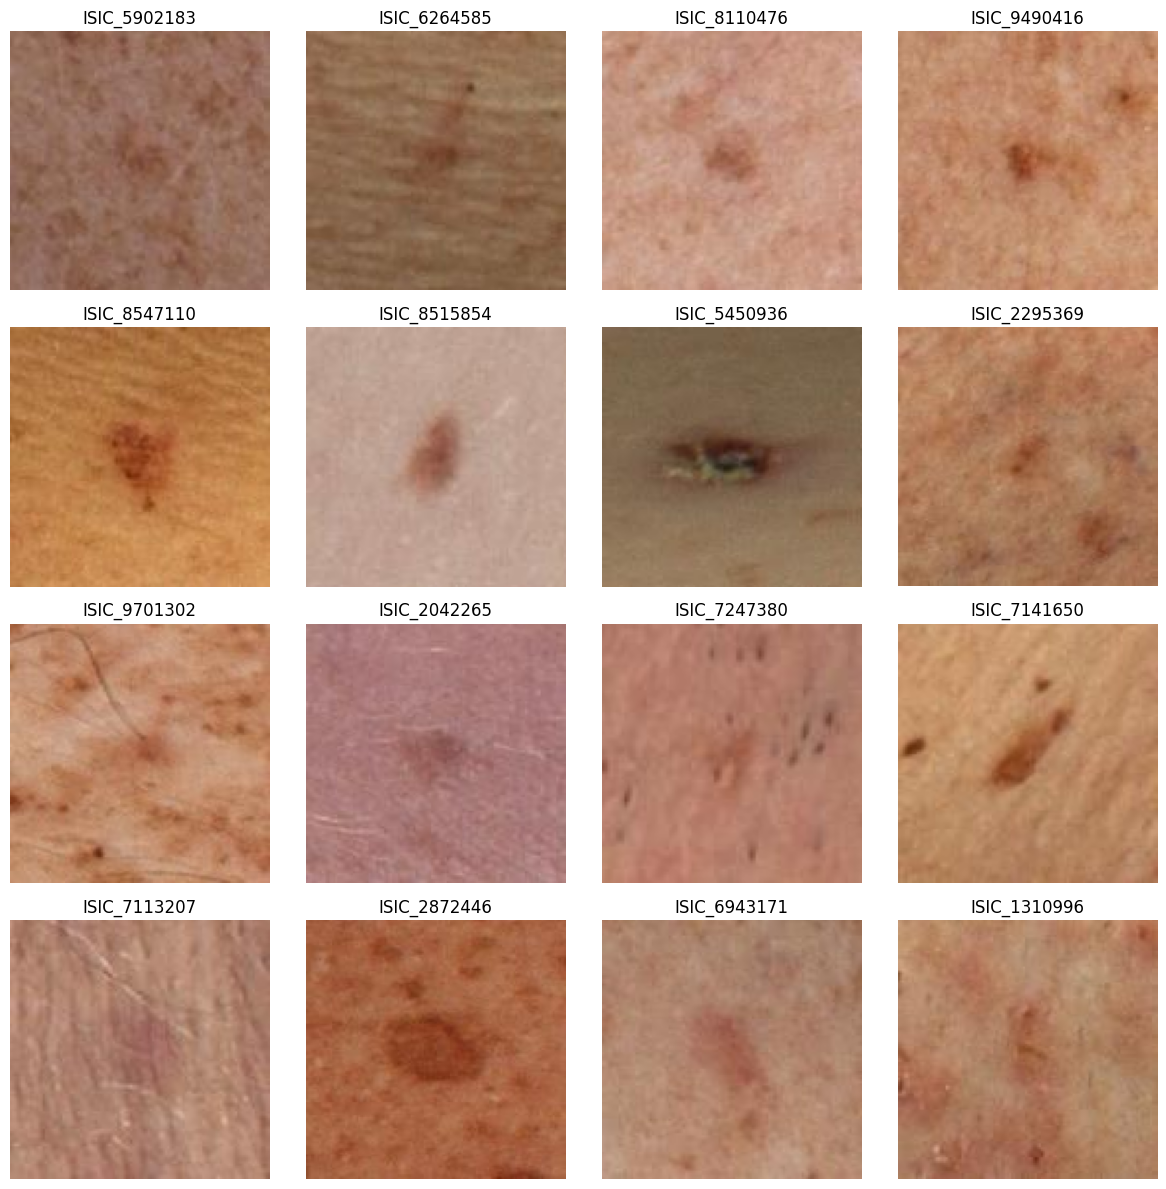

In [26]:
# Display sample images

sample_images = np.random.choice(image_files, 16, replace=False)

fig, axes = plt.subplots(4, 4, figsize=(12, 12))

for ax, img_path in zip(axes.flatten(), sample_images):
    img = Image.open(img_path)

    ax.imshow(img)
    ax.set_title(img_path.stem)
    ax.axis("off")

plt.tight_layout()
plt.show()

# Findings and Conclusions

## Dataset integrity

The image repository contains exactly **401,059 images**, matching the number of records available in the metadata files.

- Metadata records: 401,059
- Physical image files: 401,059
- Missing images: 0
- Extra images: 0

This confirms a perfect one-to-one correspondence between metadata and image files.

---

## File formats

All images are stored in JPEG format.

- JPG images: 401,059

No additional image formats were found.

---

## Image quality

No corrupted images were detected during the audit.

- Corrupted images: 0

Therefore, no image-cleaning step is required before model development.

---

## Resolution analysis

Image dimensions are highly consistent across the dataset.

Summary statistics:

- Mean resolution: 133 × 133 pixels
- Median resolution: 131 × 131 pixels
- 25th percentile: 121 × 121 pixels
- 75th percentile: 143 × 143 pixels
- Minimum resolution: 41 × 41 pixels
- Maximum resolution: 269 × 269 pixels

All images are square:

- Aspect ratio = 1.0

This greatly simplifies preprocessing because padding or aspect-ratio corrections are unnecessary.

---

## Storage footprint

The complete image repository occupies approximately:

- 1.06 GB

This size is manageable for both local experimentation and Google Colab environments.

---

## Recommended preprocessing strategy

Based on the observed resolution distribution:

### Baseline CNN

Recommended input size:

128 × 128

This resolution is close to the dataset median and minimizes interpolation effects.

### ResNet18

Recommended input size:

128 × 128

Provides a good balance between computational efficiency and information retention.

### EfficientNet-B0

Recommended input size:

160 × 160

Can be explored later in Google Colab to evaluate whether higher-resolution inputs improve performance.

---

## Final decision

The project will initially adopt:

- Resize: 128 × 128
- RGB images
- JPEG input
- Square-preserving resize
- No aspect-ratio correction

Higher resolutions will be evaluated during transfer-learning experiments.